In [ ]:
!pip install segmentation-models-pytorch timm opencv-python pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.4 MB/s eta 0:00:00a 0:00:01


In [ ]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [ ]:
!pip install --no-cache-dir torch==2.7.0 torchvision==0.22.0 torchaudio==2.7.0 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 325.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 384.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 326.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.9/663.9 MB 253.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 322.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 288.7 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 204.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.2/128.2 MB 289.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.1/204.1 MB 291.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 MB 310.0 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9

In [ ]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split, BatchSampler
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.encoders import get_preprocessing_fn
import albumentations as A
from typing import Tuple, Optional, List, Dict, Any
from torch.optim.swa_utils import AveragedModel, SWALR, update_bn

In [ ]:
# =========================
# CONFIG
# =========================
DATA_ROOT = Path(
    r"/kaggle/input/competitions/dl-lab-3-product-segmentation/train"
)
IMAGES_DIR = DATA_ROOT / "images"
MASKS_DIR = DATA_ROOT / "masks"
SAVE_DIR = Path("./seg_train_runs")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

MULTI_SCALE_SIZES = [328, 344, 352, 368]
VAL_SIZE = 352
BATCH_SIZE = 4
NUM_EPOCHS = 49
SWA_START = 39
LR = 3e-4
WEIGHT_DECAY = 1e-4
VAL_RATIO = 0.2
NUM_WORKERS = 4
SEED = 42
THRESHOLD = 0.51

MODEL_NAME = "DeepLabV3Plus"
ENCODER_NAME = "timm-efficientnet-b4"
ENCODER_WEIGHTS = "noisy-student"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# =========================
# UTILS
# =========================
def postprocess_mask(prob_mask, threshold=0.5, min_area=200):
    # binarize
    mask = (prob_mask > threshold).astype(np.uint8)

    # morphological closing (fill holes)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    filtered_mask = np.zeros_like(mask)

    for i in range(1, num_labels):  # skip background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            filtered_mask[labels == i] = 1

    return filtered_mask.astype(np.float32)


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def find_image_for_stem(images_dir: Path, stem: str) -> Path | None:
    for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"]:
        p = images_dir / f"{stem}{ext}"
        if p.exists():
            return p
    return None


def dice_score_from_logits(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > THRESHOLD).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    denom = preds_flat.sum(dim=1) + targets_flat.sum(dim=1)

    dice = (2.0 * intersection + eps) / (denom + eps)
    return dice.mean().item()


def iou_score_from_logits(logits: torch.Tensor, targets: torch.Tensor, eps: float = 1e-7) -> float:
    probs = torch.sigmoid(logits)
    preds = (probs > THRESHOLD).float()

    preds_flat = preds.view(preds.size(0), -1)
    targets_flat = targets.view(targets.size(0), -1)

    intersection = (preds_flat * targets_flat).sum(dim=1)
    union = preds_flat.sum(dim=1) + targets_flat.sum(dim=1) - intersection

    iou = (intersection + eps) / (union + eps)
    return iou.mean().item()


# =========================
# DATASET
# =========================

def get_train_augs():
    """Training augmentations (no resize - handled separately)"""
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.1),
        A.Affine(
            translate_percent=(-0.03, 0.03),
            scale=(0.95, 1.05),
            rotate=(-5, 5),
            shear=(-2, 2),
            p=0.5,
        ),
        A.OneOf([
            A.RandomBrightnessContrast(0.3, 0.3),
            A.CLAHE(),
            A.RandomGamma(),
        ], p=0.6),
        A.HueSaturationValue(5, 10, 5, p=0.3),
        A.GaussNoise(std_range=(0.01, 0.03), p=0.2),

        A.GaussianBlur(blur_limit=3, p=0.2),
        A.CoarseDropout(
            num_holes_range=(1, 6),
            hole_height_range=(0.05, 0.15),
            hole_width_range=(0.05, 0.15),
            p=0.15,
        ),
    ])


def get_val_augs():
    """Validation augmentations (none)"""
    return A.Compose([])


class BatchSizeBatchSampler(BatchSampler):
    """BatchSampler that selects a random size for each batch"""
    def __init__(self, sampler, batch_size, multi_scale_sizes, drop_last):
        super().__init__(sampler, batch_size, drop_last)
        self.multi_scale_sizes = multi_scale_sizes
        self.current_scale = None
        self.dataset = None

    def __iter__(self):
        for batch in super().__iter__():
            self.current_scale = random.choice(self.multi_scale_sizes)
            # Set current scale on dataset for access in __getitem__
            if self.dataset is not None:
                self.dataset._current_scale = self.current_scale
            yield batch


class BinarySegDataset2(Dataset):
    """
    Segmentation dataset with optional Copy-Paste augmentation using a precomputed object database.

    Args:
        images_dir: Path to directory containing input images.
        masks_dir: Path to directory containing ground truth masks (PNG).
        img_size: Target image size (square).
        encoder_name: Segmentation model encoder name (e.g., 'efficientnet-b3').
        encoder_weights: Pretrained weights ('imagenet' or None).
        transforms: Albumentations transform pipeline.
        copy_paste_prob: Probability of applying Copy-Paste augmentation (0.0 = disabled).
        cache_images: If True, load all images into RAM for faster access.
        min_object_area: Minimum area (pixels) for an object to be stored in the database.
        max_objects_per_image: Maximum number of objects to extract per image (memory control).
        multi_scale_sizes: List of sizes for multi-scale training (None for fixed size).
    """

    def __init__(
        self,
        images_dir: Path,
        masks_dir: Path,
        img_size: int = 352,
        encoder_name: str = "resnet34",
        encoder_weights: Optional[str] = "imagenet",
        transforms=None,
        copy_paste_prob: float = 0.0,
        cache_images: bool = False,
        min_object_area: int = 50,
        max_objects_per_image: int = 10,
        multi_scale_sizes: Optional[List[int]] = None,
    ):
        self.images_dir = Path(images_dir)
        self.masks_dir = Path(masks_dir)
        self.img_size = img_size
        self.transforms = transforms
        self.copy_paste_prob = copy_paste_prob
        self.cache_images = cache_images
        self.min_object_area = min_object_area
        self.max_objects_per_image = max_objects_per_image
        self.multi_scale_sizes = multi_scale_sizes
        self._current_scale = None  # Will be set by BatchSampler

        # Preprocessing function for encoder normalization
        self.preprocess_input = None
        if encoder_weights is not None:
            self.preprocess_input = get_preprocessing_fn(encoder_name, pretrained=encoder_weights)

        # Build list of (image_path, mask_path) pairs
        self.samples = []
        for mask_path in sorted(self.masks_dir.glob("*.png")):
            stem = mask_path.stem
            image_path = self._find_image_for_stem(stem)
            if image_path is not None:
                self.samples.append((image_path, mask_path))

        if not self.samples:
            raise RuntimeError(f"No paired image/mask samples found in {images_dir} and {masks_dir}")

        print(f"Found {len(self.samples)} paired samples")

        # Cache for images (if enabled)
        self._cache: Dict[int, Tuple[np.ndarray, np.ndarray]] = {}
        if self.cache_images:
            self._load_all_into_cache()

        # Object database for Copy-Paste (precomputed object crops)
        self._object_db: List[Tuple[np.ndarray, np.ndarray]] = []  # (obj_img, obj_mask)
        if self.copy_paste_prob > 0.0:
            self._build_object_database()

    def _find_image_for_stem(self, stem: str) -> Optional[Path]:
        """Find image file with given stem (case-insensitive, common extensions)."""
        for ext in [".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"]:
            p = self.images_dir / f"{stem}{ext}"
            if p.exists():
                return p
            # Try lowercase/uppercase variations if needed
            p_lower = self.images_dir / f"{stem.lower()}{ext}"
            if p_lower.exists():
                return p_lower
        return None

    def _load_all_into_cache(self):
        """Load all images and masks into RAM for faster access."""
        print("Pre-loading dataset into RAM cache...")
        for idx, (img_path, msk_path) in enumerate(self.samples):
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            msk = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
            msk = (msk > 0).astype(np.uint8)
            self._cache[idx] = (img, msk)
        print(f"Cached {len(self._cache)} images/masks")

    def _load_sample(self, idx: int, return_uint8_mask: bool = False) -> Tuple[np.ndarray, np.ndarray]:
        """
        Load image and mask by index.

        Args:
            idx: Sample index.
            return_uint8_mask: If True, return mask as uint8 (0/1), else float32.

        Returns:
            (image, mask) both as numpy arrays (H, W, 3) and (H, W).
        """
        # Check cache first
        if self.cache_images and idx in self._cache:
            img, msk_uint8 = self._cache[idx]
            img = img.copy()
            if return_uint8_mask:
                return img, msk_uint8.copy()
            else:
                return img, msk_uint8.astype(np.float32)

        # Load from disk
        img_path, msk_path = self.samples[idx]
        img = cv2.imread(str(img_path))
        if img is None:
            raise RuntimeError(f"Cannot read image: {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        msk = cv2.imread(str(msk_path), cv2.IMREAD_GRAYSCALE)
        if msk is None:
            raise RuntimeError(f"Cannot read mask: {msk_path}")

        if return_uint8_mask:
            msk = (msk > 0).astype(np.uint8)
        else:
            msk = (msk > 0).astype(np.float32)

        return img, msk

    def _build_object_database(self):
        """
        Precompute all object crops from all training images.
        Each object is stored as (object_image_crop, object_mask_crop).
        """
        print("Building object database for Copy-Paste...")
        total_objects = 0

        for idx in range(len(self.samples)):
            # Load full image and mask as uint8
            img, mask_uint8 = self._load_sample(idx, return_uint8_mask=True)

            # Find connected components (objects) in the mask
            num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(
                mask_uint8, connectivity=8
            )

            objects_in_this_image = 0
            for obj_id in range(1, num_labels):  # skip background (0)
                area = stats[obj_id, cv2.CC_STAT_AREA]
                if area < self.min_object_area:
                    continue

                # Bounding box
                x = stats[obj_id, cv2.CC_STAT_LEFT]
                y = stats[obj_id, cv2.CC_STAT_TOP]
                w = stats[obj_id, cv2.CC_STAT_WIDTH]
                h = stats[obj_id, cv2.CC_STAT_HEIGHT]

                # Crop object image and mask
                obj_img = img[y:y+h, x:x+w].copy()
                obj_mask = (labels[y:y+h, x:x+w] == obj_id).astype(np.uint8)

                # Store in database
                self._object_db.append((obj_img, obj_mask))
                total_objects += 1
                objects_in_this_image += 1

                # Limit per image to avoid excessive memory
                if objects_in_this_image >= self.max_objects_per_image:
                    break

        print(f"Precomputed {total_objects} objects for Copy-Paste from {len(self.samples)} images")
        if total_objects == 0:
            print("Warning: No objects found for Copy-Paste. Augmentation will be disabled.")
            self.copy_paste_prob = 0.0

    def _copy_paste(self, image: np.ndarray, mask: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """
        Paste a random precomputed object into the image and mask.

        Args:
            image: (H, W, 3) uint8 image.
            mask: (H, W) uint8 mask (0/1).

        Returns:
            Augmented (image, mask).
        """
        if not self._object_db:
            return image, mask

        # Randomly select an object from the database
        obj_img, obj_mask = random.choice(self._object_db)
        obj_h, obj_w = obj_img.shape[:2]
        img_h, img_w = image.shape[:2]

        # Skip if object is larger than image (should not happen with proper resizing, but safe)
        if obj_h >= img_h or obj_w >= img_w:
            return image, mask

        # Random paste location
        py = random.randint(0, img_h - obj_h)
        px = random.randint(0, img_w - obj_w)

        # Paste object image (only where object mask is 1)
        roi_img = image[py:py+obj_h, px:px+obj_w]
        roi_img[obj_mask == 1] = obj_img[obj_mask == 1]
        image[py:py+obj_h, px:px+obj_w] = roi_img

        # Update mask
        mask[py:py+obj_h, px:px+obj_w][obj_mask == 1] = 1

        return image, mask

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        # Load primary sample
        image, mask = self._load_sample(idx, return_uint8_mask=False)

        # Copy-Paste augmentation (if enabled)
        if self.copy_paste_prob > 0.0 and random.random() < self.copy_paste_prob:
            mask_uint8 = (mask > 0).astype(np.uint8)
            image, mask_uint8 = self._copy_paste(image, mask_uint8)
            mask = mask_uint8.astype(np.float32)

        # Determine target size
        # For multi-scale training, use the scale set by BatchSampler
        if self.multi_scale_sizes is not None and self._current_scale is not None:
            target_size = self._current_scale
        else:
            target_size = self.img_size

        # Apply resize
        resize_aug = A.Compose([
            A.LongestMaxSize(max_size=target_size),
            A.PadIfNeeded(target_size, target_size, border_mode=0),
        ])
        augmented = resize_aug(image=image, mask=mask)
        image = augmented["image"]
        mask = augmented["mask"]

        # Apply other transforms (augmentations for train, empty for val)
        if self.transforms is not None:
            augmented = self.transforms(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        # Convert to tensor and apply encoder preprocessing
        if isinstance(image, np.ndarray):
            if self.preprocess_input is not None:
                image = self.preprocess_input(image)
            else:
                image = image / 255.0
            image = torch.from_numpy(image.transpose(2, 0, 1)).float()

        if isinstance(mask, np.ndarray):
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        elif hasattr(mask, 'dim') and mask.dim() == 2:
            mask = mask.unsqueeze(0).float()

        return image, mask


# =========================
# MODEL
# =========================
def build_model() -> nn.Module:
    if MODEL_NAME == "Unet":
        model = smp.Unet(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif MODEL_NAME == "UnetPlusPlus":
        model = smp.UnetPlusPlus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif MODEL_NAME == "FPN":
        model = smp.FPN(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif MODEL_NAME == "DeepLabV3Plus":
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=ENCODER_WEIGHTS,
            encoder_output_stride=8,
            decoder_channels=256,
            decoder_atrous_rates=(12, 24, 36),
            in_channels=3,
            classes=1,
            activation=None,
            upsampling=4,
        )
    else:
        raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}")
    return model


# =========================
# TRAIN / VAL LOOPS
# =========================
def train_one_epoch(model, loader, optimizer, loss_fn, device, scheduler=None):
    model.train()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    scaler = torch.amp.GradScaler('cuda') if device == "cuda" else None

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if device == "cuda":
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = loss_fn(logits, masks)
        else:
            logits = model(images)
            loss = loss_fn(logits, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        if scheduler is not None:
            scheduler.step()


        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits.detach(), masks)
        running_iou += iou_score_from_logits(logits.detach(), masks)


    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


@torch.no_grad()
def validate_one_epoch(model, loader, loss_fn, device):
    model.eval()

    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = loss_fn(logits, masks)

        running_loss += loss.item()
        running_dice += dice_score_from_logits(logits, masks)
        running_iou += iou_score_from_logits(logits, masks)

    n = len(loader)
    return {
        "loss": running_loss / n,
        "dice": running_dice / n,
        "iou": running_iou / n,
    }


# =========================
# MAIN
# =========================
def main():
    seed_everything(SEED)

    # Create datasets
    train_dataset = BinarySegDataset2(
        IMAGES_DIR, MASKS_DIR,
        img_size=VAL_SIZE,  # Fallback size (not used with multi-scale)
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        transforms=get_train_augs(),
        copy_paste_prob=0.2,
        cache_images=True,
        min_object_area=50,
        max_objects_per_image=5,
        multi_scale_sizes=MULTI_SCALE_SIZES,  # Enable multi-scale
    )

    val_dataset = BinarySegDataset2(
        IMAGES_DIR, MASKS_DIR,
        img_size=VAL_SIZE,  # Fixed size for validation
        encoder_name=ENCODER_NAME,
        encoder_weights=ENCODER_WEIGHTS,
        transforms=get_val_augs(),
        copy_paste_prob=0.0,
        cache_images=False,
        multi_scale_sizes=None,  # No multi-scale for validation
    )

    # Split indices
    indices = list(range(len(train_dataset)))
    random.shuffle(indices)
    split = int(len(indices) * VAL_RATIO)

    train_indices = indices[split:]
    val_indices = indices[:split]

    train_subset = torch.utils.data.Subset(train_dataset, train_indices)
    val_subset = torch.utils.data.Subset(val_dataset, val_indices)

    print(f"Train samples: {len(train_subset)}, Val samples: {len(val_subset)}")

    # Create batch sampler for multi-scale training
    train_sampler = torch.utils.data.RandomSampler(train_subset)
    train_batch_sampler = BatchSizeBatchSampler(
        train_sampler, BATCH_SIZE, MULTI_SCALE_SIZES, drop_last=False
    )

    # Set reference to dataset for scale access
    train_batch_sampler.dataset = train_dataset

    train_loader = DataLoader(
        train_subset,
        batch_sampler=train_batch_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True if DEVICE == "cuda" else False,
    )

    val_loader = DataLoader(
        val_subset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True if DEVICE == "cuda" else False,
        drop_last=False,
    )

    # Loss functions
    lovasz = smp.losses.LovaszLoss(mode="binary", per_image=True)
    dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
    def loss_fn(logits, targets):
        return 0.6 * lovasz(logits, targets) + 0.4 * dice(logits, targets)

    model = build_model().to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=7, T_mult=2, eta_min=1e-6)

    swa_model = AveragedModel(model)
    swa_scheduler = SWALR(optimizer, swa_lr=LR/10, anneal_epochs=5)

    best_val_dice = -1.0
    best_swa_dice = -1.0
    history = []

    print(f"Training with multi-scale sizes: {MULTI_SCALE_SIZES}")
    print(f"Validation size: {VAL_SIZE}")
    def get_aug_factor(epoch):
        if epoch <= 25:
            return 1.00
        elif epoch <= 30:
            return 0.95
        elif epoch <= 35:
            return 0.9
        elif epoch <= 45:
            return 0.85
        else:
            return 0.8


    def aug_scheduler(dataset, factor):
        if hasattr(dataset, 'copy_paste_prob'):
            dataset.copy_paste_prob = 0.2 * factor

        # Helper to recursively scale probabilities
        def scale_transform(transform):
            # Handle OneOf (which contains a list of transforms)
            if isinstance(transform, A.OneOf):
                for sub_t in transform.transforms:
                    scale_transform(sub_t)
            # Handle Compose (though usually top-level)
            elif isinstance(transform, A.Compose):
                for sub_t in transform.transforms:
                    scale_transform(sub_t)
            # Handle individual augmentations
            if hasattr(transform, 'p'):
                # Store original probability if not already stored
                if not hasattr(transform, '_original_p'):
                    transform._original_p = transform.p
                # Apply scaling
                transform.p = transform._original_p * factor

        # Apply to all transforms in the dataset's Compose pipeline
        for t in dataset.transforms.transforms:
            scale_transform(t)


    for epoch in range(1, NUM_EPOCHS + 1):
        aug_factor = get_aug_factor(epoch)
        aug_scheduler(train_dataset, aug_factor)

        train_metrics = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)

        if epoch >= SWA_START:
            swa_model.update_parameters(model)
            swa_scheduler.step()

            val_metrics = validate_one_epoch(swa_model, val_loader, loss_fn, DEVICE)

            if val_metrics["dice"] > best_swa_dice:
                best_swa_dice = val_metrics["dice"]
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": swa_model.state_dict(),
                    "val_dice": best_swa_dice,
                    "type": "swa",
                }, SAVE_DIR / "best_swa.pth")
                print(f"Saved new best SWA model with val_dice={best_swa_dice:.4f}")
        else:
            scheduler.step()

            # Validate with regular model
            val_metrics = validate_one_epoch(model, val_loader, loss_fn, DEVICE)

            if val_metrics["dice"] > best_val_dice:
                best_val_dice = val_metrics["dice"]
                torch.save({
                    "epoch": epoch,
                    "model_state_dict": model.state_dict(),
                    "val_dice": best_val_dice,
                    "type": "regular",
                }, SAVE_DIR / "best_regular.pth")
                print(f"Saved new best regular model with val_dice={best_val_dice:.4f}")

        row = {
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "train_loss": train_metrics["loss"],
            "train_dice": train_metrics["dice"],
            "train_iou": train_metrics["iou"],
            "val_loss": val_metrics["loss"],
            "val_dice": val_metrics["dice"],
            "val_iou": val_metrics["iou"],
        }
        history.append(row)

        print(
            f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
            f"train_loss={row['train_loss']:.4f} train_dice={row['train_dice']:.4f} train_iou={row['train_iou']:.4f} | "
            f"val_loss={row['val_loss']:.4f} val_dice={row['val_dice']:.4f} val_iou={row['val_iou']:.4f}"
        )

        # Save last
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_dice": row["val_dice"],
                "config": {
                    "MODEL_NAME": MODEL_NAME,
                    "ENCODER_NAME": ENCODER_NAME,
                    "ENCODER_WEIGHTS": ENCODER_WEIGHTS,
                    "VAL_SIZE": VAL_SIZE,
                    "MULTI_SCALE_SIZES": MULTI_SCALE_SIZES,
                },
            },
            SAVE_DIR / "last.pth",
        )


    print("Updating BatchNorm statistics for SWA model...")
    swa_model.train()
    update_bn(train_loader, swa_model, device=DEVICE)
    swa_model.eval()
    final_metrics = validate_one_epoch(swa_model, val_loader, loss_fn, DEVICE)
    print(f"Final SWA model after BN update: val_dice={final_metrics['dice']:.4f}")

    # Save final SWA model
    torch.save(
        {
            "model_state_dict": swa_model.state_dict(),
            "val_dice": final_metrics["dice"],
            "type": "swa_final",
            "config": {
                "MODEL_NAME": MODEL_NAME,
                "ENCODER_NAME": ENCODER_NAME,
                "ENCODER_WEIGHTS": ENCODER_WEIGHTS,
                "VAL_SIZE": VAL_SIZE,
                "MULTI_SCALE_SIZES": MULTI_SCALE_SIZES,
        },
    }, SAVE_DIR / "swa_final.pth")

    # Save history
    history_df = pd.DataFrame(history)
    history_df.to_csv(SAVE_DIR / "history.csv", index=False)
    print(f"Training finished. Best val_dice={best_val_dice:.4f}")


#if __name__ == "__main__":
    #main()

In [ ]:
def get_finetune_augs():
    return A.Compose([
        A.HorizontalFlip(p=0.3),
        A.VerticalFlip(p=0.05),
        A.Affine(translate_percent=(-0.01,0.01), scale=(0.99,1.01), rotate=(-2,2), p=0.2),
        A.RandomBrightnessContrast(0.1, 0.1, p=0.1),
    ])

In [ ]:
import torch.nn.functional as F
from torch.amp import GradScaler, autocast
# =========================
# DISTILLATION CONFIG
# =========================
DISTILL_EPOCHS = 5
DISTILL_LR = 1e-5
DISTILL_TEMPERATURE = 2.0  # Softens probability distributions
DISTILL_ALPHA = 0.9  # Weight for ground truth loss vs distillation loss

# =========================
# DISTILLATION TRAINING
# =========================

class DistillationTrainer:
    """
    Knowledge distillation from two teacher models to a single student.
    Student learns from both ground truth labels and teacher ensemble predictions.
    """
    def __init__(
        self,
        student_model,
        teacher_model1,
        teacher_model2,
        teacher1_weight=0.65,  # Epoch 20 performed better
        teacher2_weight=0.35,  # SWA model
        temperature=2.0,
        alpha=0.9,
        device='cuda'
    ):
        self.teacher1_weight = teacher1_weight
        self.teacher2_weight = teacher2_weight
        self.temperature = temperature
        self.alpha = alpha
        self.device = device
        self.gpu0 = torch.device('cuda:0')
        self.gpu1 = torch.device('cuda:1') if torch.cuda.device_count() > 1 else self.gpu0

        print(f"Teacher 1 on: {self.gpu0}")
        print(f"Teacher 2 on: {self.gpu1}")
        print(f"Student on: {self.gpu0} (with DataParallel if 2 GPUs)")

        if torch.cuda.device_count() > 1:
            self.student = nn.DataParallel(student_model)
        else:
            self.student = student_model
        self.student = self.student.to(self.gpu0)

        self.teacher1 = teacher_model1.to(self.gpu0)
        self.teacher1.eval()
        for param in self.teacher1.parameters():
            param.requires_grad = False

        # Teacher 2 on GPU 1
        self.teacher2 = teacher_model2.to(self.gpu1)
        self.teacher2.eval()
        for param in self.teacher2.parameters():
            param.requires_grad = False


    def distillation_loss(self, student_logits, teacher_probs, targets):
        hard_loss = loss_fn(student_logits, targets)
        student_probs = torch.sigmoid(student_logits / self.temperature)
        soft_loss = F.mse_loss(student_probs, teacher_probs) * (self.temperature ** 2)
        total_loss = self.alpha * hard_loss + (1 - self.alpha) * soft_loss
        return total_loss, hard_loss, soft_loss

    @torch.no_grad()
    def get_teacher_ensemble(self, images):
        # Images are on GPU 0
        images_gpu0 = images.to(self.gpu0)

        # Teacher 1 on GPU 0 (fast, no transfer)
        logits1 = self.teacher1(images_gpu0)
        probs1 = torch.sigmoid(logits1 / self.temperature)

        # Teacher 2 on GPU 1 (need to transfer)
        images_gpu1 = images.to(self.gpu1)
        logits2 = self.teacher2(images_gpu1)
        probs2 = torch.sigmoid(logits2 / self.temperature)

        # Bring back to GPU 0 for ensemble
        probs2 = probs2.to(self.gpu0)

        # Weighted ensemble
        ensemble = self.teacher1_weight * probs1 + self.teacher2_weight * probs2

        return ensemble


def train_distillation_one_epoch(trainer, loader, optimizer, device):
    """
    One epoch of distillation training.
    """
    trainer.student.train()

    running_total_loss = 0.0
    running_hard_loss = 0.0
    running_soft_loss = 0.0
    running_dice = 0.0

    scaler = torch.amp.GradScaler('cuda') if device == "cuda" else None

    for images, masks in loader:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Get teacher ensemble predictions (frozen, no grad)
        teacher_probs = trainer.get_teacher_ensemble(images)

        if device == "cuda":
            with torch.amp.autocast('cuda'):
                student_logits = trainer.student(images)
                loss, hard_loss, soft_loss = trainer.distillation_loss(
                    student_logits, teacher_probs, masks
                )
        else:
            student_logits = trainer.student(images)
            loss, hard_loss, soft_loss = trainer.distillation_loss(
                student_logits, teacher_probs, masks
            )

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(trainer.student.parameters(), 10.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainer.student.parameters(), 10.0)
            optimizer.step()

        running_total_loss += loss.item()
        running_hard_loss += hard_loss.item()
        running_soft_loss += soft_loss.item()
        running_dice += dice_score_from_logits(student_logits.detach(), masks)

    n = len(loader)
    return {
        "total_loss": running_total_loss / n,
        "hard_loss": running_hard_loss / n,
        "soft_loss": running_soft_loss / n,
        "dice": running_dice / n,
    }


def run_distillation(
    teacher1_checkpoint_path,
    teacher2_checkpoint_path,
    full_dataset,
    batch_size=BATCH_SIZE,
    epochs=DISTILL_EPOCHS,
    lr=DISTILL_LR,
    device=DEVICE
):
    """
    Main distillation training loop.
    """
    print("=" * 50)
    print("Starting Knowledge Distillation")
    print("=" * 50)

    # Load teacher models
    print("\n1. Loading teacher models...")

    teacher1 = build_model().to(device)
    checkpoint1 = torch.load(teacher1_checkpoint_path)
    teacher1.load_state_dict(checkpoint1['model_state_dict'])
    print(f"   Teacher 1 (epoch 20): val_dice = {checkpoint1.get('val_dice', 'N/A')}")

    teacher2 = build_model().to(device)
    checkpoint2 = torch.load(teacher2_checkpoint_path)
    teacher2.load_state_dict(checkpoint2['model_state_dict'])
    print(f"   Teacher 2 (SWA): val_dice = {checkpoint2.get('val_dice', 'N/A')}")

    # Create student model (same architecture)
    print("\n2. Creating student model...")
    student = build_model()
    student.load_state_dict(checkpoint1['model_state_dict'])
    student.to(device)

    # Create data loader
    print("\n3. Preparing full dataset loader...")
    sampler = torch.utils.data.RandomSampler(full_dataset)
    batch_sampler = BatchSizeBatchSampler(
        sampler, batch_size, MULTI_SCALE_SIZES, drop_last=False
    )
    batch_sampler.dataset = full_dataset

    full_loader = DataLoader(
        full_dataset,
        batch_sampler=batch_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True if device == "cuda" else False,
    )

    # Initialize trainer
    print("\n4. Setting up distillation trainer...")
    trainer = DistillationTrainer(
        student_model=student,
        teacher_model1=teacher1,
        teacher_model2=teacher2,
        teacher1_weight=0.7,  # Epoch 20 gets higher weight
        teacher2_weight=0.3,  # SWA gets lower weight
        temperature=DISTILL_TEMPERATURE,
        alpha=DISTILL_ALPHA,
        device=device
    )

    # Optimizer
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)

    # Simple learning rate scheduler (optional)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

    # Training loop
    print("\n5. Starting distillation training...")
    print(f"   Epochs: {epochs}")
    print(f"   Learning rate: {lr}")
    print(f"   Temperature: {DISTILL_TEMPERATURE}")
    print(f"   Alpha (hard loss weight): {DISTILL_ALPHA}")
    print("-" * 50)

    best_dice = 0.0
    history = []

    teacher1.eval()
    teacher2.eval()

    if hasattr(student.encoder, 'set_grad_checkpointing'):
        student.encoder.set_grad_checkpointing(True)
        torch.cuda.empty_cache()

    for epoch in range(1, epochs + 1):
        metrics = train_distillation_one_epoch(trainer, full_loader, optimizer, device)
        scheduler.step()

        history.append({
            "epoch": epoch,
            "lr": optimizer.param_groups[0]["lr"],
            **metrics
        })

        print(f"Epoch {epoch}/{epochs} | "
              f"Total Loss: {metrics['total_loss']:.4f} | "
              f"Hard Loss: {metrics['hard_loss']:.4f} | "
              f"Soft Loss: {metrics['soft_loss']:.4f} | "
              f"Dice: {metrics['dice']:.4f}")

        # Save checkpoint
        checkpoint = {
            "epoch": epoch,
            "model_state_dict": student.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_dice": metrics["dice"],
            "config": {
                "temperature": DISTILL_TEMPERATURE,
                "alpha": DISTILL_ALPHA,
                "teacher1_weight": 0.65,
                "teacher2_weight": 0.35,
            }
        }

        torch.save(checkpoint, SAVE_DIR / f"distilled_epoch{epoch}.pth")

        if metrics["dice"] > best_dice:
            best_dice = metrics["dice"]
            torch.save(checkpoint, SAVE_DIR / "distilled_best.pth")
            print(f"   → Saved new best model (dice={best_dice:.4f})")

    print("\n" + "=" * 50)
    print(f"Distillation complete! Best train dice: {best_dice:.4f}")
    print("=" * 50)

    return student, history


# =========================
# MAIN EXECUTION
# =========================
if __name__ == "__main__":
    # Paths to your best models
    TEACHER2_PATH = "/kaggle/working/swa_cleaner.pth"
    TEACHER1_PATH = "/kaggle/input/models/meowmeowmeeowww/best-regular/tensorflow2/default/1/best_regular.pth"

    # Create full dataset (no validation split)
    full_dataset = BinarySegDataset2(
        IMAGES_DIR, MASKS_DIR,
        img_size=VAL_SIZE,
        encoder_name=ENCODER_NAME,
        encoder_weights=None,  # Weights loaded manually
        transforms=get_finetune_augs(),  # Light augmentations
        copy_paste_prob=0.1,  # Reduced for fine-tuning
        cache_images=True,
        min_object_area=50,
        max_objects_per_image=5,
        multi_scale_sizes=[336, 352, 368],  # Tighter range for distillation
    )

    print(f"Full dataset size: {len(full_dataset)} samples")

    lovasz = smp.losses.LovaszLoss(mode="binary", per_image=True)
    dice = smp.losses.DiceLoss(mode="binary", from_logits=True)
    def loss_fn(logits, targets):
        return 0.6 * lovasz(logits, targets) + 0.4 * dice(logits, targets)

    # Run distillation
    distilled_model, history = run_distillation(
        teacher1_checkpoint_path=TEACHER1_PATH,
        teacher2_checkpoint_path=TEACHER2_PATH,
        full_dataset=full_dataset,
        batch_size=4,
        epochs=5,
        lr=DISTILL_LR,
        device=DEVICE
    )

    # Save history
    history_df = pd.DataFrame(history)
    history_df.to_csv(SAVE_DIR / "distillation_history.csv", index=False)

    print("\nDistilled model saved as 'distilled_best.pth'")
    print("Use this model for Kaggle submission with TTA!")

Found 2000 paired samples
Pre-loading dataset into RAM cache...
Cached 2000 images/masks
Building object database for Copy-Paste...
Precomputed 2379 objects for Copy-Paste from 2000 images
Full dataset size: 2000 samples
Starting Knowledge Distillation

1. Loading teacher models...


TypeError: build_model() missing 2 required positional arguments: 'model_name' and 'encoder_name'

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

def recalibrate_batchnorm(model, loader, device, num_batches=50):
    """
    Recalibrate BatchNorm running statistics using training data.
    This fixes the corrupted BN stats without changing weights.
    """
    model.train()  # Must be in train mode to update running stats

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= num_batches:
                break

            images = images.to(device)

            # Forward pass to update running stats
            _ = model(images)

            if i % 10 == 0:
                print(f"  Recalibrating batch {i+1}/{num_batches}")

    model.eval()
    print("BatchNorm recalibration complete!")
    return model

# Load the broken model
print("Loading distilled model...")
checkpoint = torch.load(CHECKPOINT_PATH, map_location='cpu')
model = build_model()
state_dict = checkpoint['model_state_dict']
model.load_state_dict(state_dict)
model = model.to(DEVICE)

# Create a small calibration dataset (use training data)
# IMPORTANT: Use the SAME normalization as training!
calib_dataset = BinarySegDataset2(
    IMAGES_DIR, MASKS_DIR,
    img_size=VAL_SIZE,
    encoder_name=ENCODER_NAME,
    encoder_weights=ENCODER_WEIGHTS,  # CRITICAL: Same as training!
    transforms=get_val_augs(),  # No augmentation for calibration
    copy_paste_prob=0.0,
    cache_images=False,
    multi_scale_sizes=None,
)

# Use a subset for quick calibration
indices = list(range(min(500, len(calib_dataset))))  # 500 images is enough
calib_subset = torch.utils.data.Subset(calib_dataset, indices)

calib_loader = DataLoader(
    calib_subset,
    batch_size=8,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("Recalibrating BatchNorm statistics...")
model = recalibrate_batchnorm(model, calib_loader, DEVICE, num_batches=50)

# Save the fixed checkpoint
fixed_checkpoint = {
    'epoch': checkpoint['epoch'],
    'model_state_dict': model.state_dict(),
    'train_dice': checkpoint['train_dice'],
    'config': checkpoint['config'],
    'fixed_bn': True
}
torch.save(fixed_checkpoint, SAVE_DIR / "distilled_best_fixed.pth")
print("Fixed checkpoint saved!")

# Now evaluate
print("\nEvaluating fixed model...")
model.eval()
metrics = evaluate(model, val_loader)
print(f"Validation Dice: {metrics['dice']:.4f}")

Loading distilled model...
Found 2000 paired samples
Recalibrating BatchNorm statistics...
  Recalibrating batch 1/50
  Recalibrating batch 11/50
  Recalibrating batch 21/50
  Recalibrating batch 31/50
  Recalibrating batch 41/50
BatchNorm recalibration complete!
Fixed checkpoint saved!

Evaluating fixed model...
Validation Dice: 0.9153


In [ ]:
import json
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.encoders import get_preprocessing_fn


# =========================
# CONFIG
# =========================
TEST_IMAGES_DIR = Path(
    r"/kaggle/input/competitions/dl-lab-3-product-segmentation/test_images"
)
OUTPUT_CSV = "distilled_submission_try3.csv"

# путь к вашему чекпоинту после обучения
CHECKPOINT_PATH = Path(r"/kaggle/working/seg_train_runs/distilled_best_fixed.pth")

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
THRESHOLD = 0.5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"



# =========================
# HELPERS
# =========================
def cv2_imread_unicode(path: Path, flags=cv2.IMREAD_COLOR):
    data = np.fromfile(str(path), dtype=np.uint8)
    if data.size == 0:
        return None
    return cv2.imdecode(data, flags)


def build_model(model_name: str, encoder_name: str, encoder_weights=None):
    if model_name == "Unet":
        model = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif model_name == "UnetPlusPlus":
        model = smp.UnetPlusPlus(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif model_name == "FPN":
        model = smp.FPN(
            encoder_name=encoder_name,
            encoder_weights=encoder_weights,
            in_channels=3,
            classes=1,
            activation=None,
        )
    elif MODEL_NAME == "DeepLabV3Plus":
        model = smp.DeepLabV3Plus(
            encoder_name=ENCODER_NAME,
            encoder_weights=None,
            encoder_output_stride=8,
            decoder_channels=256,
            decoder_atrous_rates=(12, 24, 36),
            in_channels=3,
            classes=1,
            activation=None,
            upsampling=4,
        )
    else:
        raise ValueError(f"Unsupported MODEL_NAME: {model_name}")
    return model




def serialize_mask(mask2d: np.ndarray) -> str:
    return json.dumps(mask2d.astype(np.uint8).tolist(), separators=(",", ":"))


# =========================
# LOAD CHECKPOINT
# =========================
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

'''if "config" not in checkpoint:
    raise ValueError("Checkpoint does not contain 'config'.")

cfg = checkpoint["config"]

MODEL_NAME = cfg["MODEL_NAME"]
ENCODER_NAME = cfg["ENCODER_NAME"]
ENCODER_WEIGHTS = cfg.get("ENCODER_WEIGHTS", None)
IMG_SIZE = int(cfg["VAL_SIZE"])

print("Loaded checkpoint config:")
print("MODEL_NAME     =", MODEL_NAME)
print("ENCODER_NAME   =", ENCODER_NAME)
print("ENCODER_WEIGHTS=", ENCODER_WEIGHTS)
print("IMG_SIZE       =", IMG_SIZE)
'''
MODEL_NAME     = 'DeepLabV3Plus'
ENCODER_NAME   = 'timm-efficientnet-b4'
ENCODER_WEIGHTS= 'noisy-student'
IMG_SIZE       = 352

model = build_model(
    model_name=MODEL_NAME,
    encoder_name=ENCODER_NAME,
    encoder_weights=None,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

preprocess_input = None
if ENCODER_WEIGHTS is not None:
    preprocess_input = get_preprocessing_fn(ENCODER_NAME, pretrained=ENCODER_WEIGHTS)


# =========================
# INFERENCE
# =========================
image_paths = sorted([p for p in TEST_IMAGES_DIR.rglob("*") if p.suffix.lower() in IMG_EXTS])

if not image_paths:
    raise FileNotFoundError(f"No images found in: {TEST_IMAGES_DIR}")

print(f"Found {len(image_paths)} test images")

rows = []

with torch.no_grad():
    for i, img_path in enumerate(image_paths, 1):
        img_bgr = cv2_imread_unicode(img_path, cv2.IMREAD_COLOR)
        if img_bgr is None:
            print(f"[skip] cannot read: {img_path}")
            continue

        H, W = img_bgr.shape[:2]
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # resize под вход модели
        inp = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_LINEAR)
        inp = inp.astype(np.float32)

        if preprocess_input is not None:
            inp = preprocess_input(inp)
        else:
            inp = inp / 255.0

        inp = torch.from_numpy(inp.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

        logits = model(inp)                      # [1, 1, H, W]
        probs = torch.sigmoid(logits)[0, 0]      # [H, W]
        pred = probs.detach().cpu().numpy()

        # возвращаем в исходный размер
        if pred.shape != (H, W):
            pred = cv2.resize(pred.astype(np.float32), (W, H), interpolation=cv2.INTER_LINEAR)

        mask = (pred > THRESHOLD).astype(np.uint8)

        rows.append(
            {
                "ImageId": img_path.name,
                "mask": serialize_mask(mask),
            }
        )

        if i % 100 == 0 or i == len(image_paths):
            print(f"Processed {i}/{len(image_paths)}")

submission_df = pd.DataFrame(rows)
submission_df.to_csv(OUTPUT_CSV, index=False, encoding="utf-8")

print("Done.")
print(f"Saved submission to: {OUTPUT_CSV}")
print(submission_df.head())

Found 2000 test images
Processed 100/2000
Processed 200/2000
Processed 300/2000
Processed 400/2000
Processed 500/2000
Processed 600/2000
Processed 700/2000
Processed 800/2000
Processed 900/2000
Processed 1000/2000
Processed 1100/2000
Processed 1200/2000
Processed 1300/2000
Processed 1400/2000
Processed 1500/2000
Processed 1600/2000
Processed 1700/2000
Processed 1800/2000
Processed 1900/2000
Processed 2000/2000
Done.
Saved submission to: distilled_submission_try3.csv
                                             ImageId  \
0  10.107.215.111_20260119142748_a0be018c-d498-4b...   
1  10.107.215.111_20260119203335_58a6ef5c-c360-4e...   
2  10.107.215.111_20260119203341_bb74ac11-3f14-4a...   
3  10.107.215.111_20260122115937_db9b4af5-0f1e-42...   
4  10.107.215.111_20260124135952_6fd575ec-50e8-4f...   

                                                mask  
0  [[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...  
1  [[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...  
2  [[0,0,0,0,0,0,0,0,0,0,0,

In [ ]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm
import segmentation_models_pytorch as smp
from segmentation_models_pytorch.encoders import get_preprocessing_fn

# =========================
# CONFIGURATION
# =========================
UNLABELLED_IMAGES_DIR = Path("/kaggle/input/competitions/dl-lab-3-product-segmentation/unlabeled/images")  # adjust path
OUTPUT_MASKS_DIR = Path("/kaggle/working/pseudo_masks")
OUTPUT_MASKS_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = Path("/kaggle/working/seg_train_runs/distilled_best_fixed.pth")
IMG_SIZE = 352
THRESHOLD = 0.54
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ENCODER_NAME = "timm-efficientnet-b4"
ENCODER_WEIGHTS = "noisy-student"

# =========================
# LOAD MODEL
# =========================
def build_model():
    model = smp.DeepLabV3Plus(
        encoder_name=ENCODER_NAME,
        encoder_weights=None,
        encoder_output_stride=8,
        decoder_channels=256,
        decoder_atrous_rates=(12, 24, 36),
        in_channels=3,
        classes=1,
        activation=None,
        upsampling=4,
    )
    return model

checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")
model = build_model()
state_dict = checkpoint["model_state_dict"]
if list(state_dict.keys())[0].startswith("module."):
    state_dict = {k[7:]: v for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model = model.to(DEVICE)
model.eval()

preprocess_fn = get_preprocessing_fn(ENCODER_NAME, pretrained=ENCODER_WEIGHTS)

# =========================
# TTA + POSTPROCESSING
# =========================
def postprocess_mask(prob, threshold=THRESHOLD, min_area=200):
    """Clean mask with morphological closing and small object removal."""
    mask = (prob > threshold).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    filtered = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            filtered[labels == i] = 1
    return filtered

@torch.no_grad()
def predict_tta(image_rgb, scales=(0.75, 1.0, 1.25), flips=True):
    """Multi-scale TTA with horizontal/vertical flips."""
    h, w = image_rgb.shape[:2]
    preds = []
    for scale in scales:
        new_size = int(IMG_SIZE * scale)
        inp = cv2.resize(image_rgb, (new_size, new_size), interpolation=cv2.INTER_LINEAR)
        inp = preprocess_fn(inp.astype(np.float32))
        inp_tensor = torch.from_numpy(inp.transpose(2, 0, 1)).float().unsqueeze(0).to(DEVICE)

        # Original
        logits = model(inp_tensor)
        prob = torch.sigmoid(logits)
        prob = F.interpolate(prob, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        preds.append(prob)

        if flips:
            # Horizontal flip
            logits_h = model(torch.flip(inp_tensor, dims=[-1]))
            prob_h = torch.flip(torch.sigmoid(logits_h), dims=[-1])
            prob_h = F.interpolate(prob_h, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
            preds.append(prob_h)

            # Vertical flip
            logits_v = model(torch.flip(inp_tensor, dims=[-2]))
            prob_v = torch.flip(torch.sigmoid(logits_v), dims=[-2])
            prob_v = F.interpolate(prob_v, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
            preds.append(prob_v)

    # Average all predictions
    final_prob = torch.stack(preds).mean(dim=0)[0, 0].cpu().numpy()
    final_prob = cv2.resize(final_prob, (w, h), interpolation=cv2.INTER_LINEAR)
    return final_prob

# =========================
# GENERATE PSEUDO-LABELS
# =========================
image_paths = sorted([p for p in UNLABELLED_IMAGES_DIR.glob("*") if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
print(f"Found {len(image_paths)} unlabelled images")

for img_path in tqdm(image_paths, desc="Pseudo-labeling"):
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # TTA prediction
    prob = predict_tta(img_rgb, scales=(0.75, 1.0, 1.25), flips=True)

    # Postprocess and save
    mask = postprocess_mask(prob, threshold=THRESHOLD, min_area=200)
    mask_path = OUTPUT_MASKS_DIR / f"{img_path.stem}.png"
    cv2.imwrite(str(mask_path), mask * 255)

print(f"Pseudo-masks saved to {OUTPUT_MASKS_DIR}")

Found 350 unlabelled images


Pseudo-labeling: 100%|██████████| 350/350 [03:40<00:00,  1.59it/s]

Pseudo-masks saved to /kaggle/working/pseudo_masks


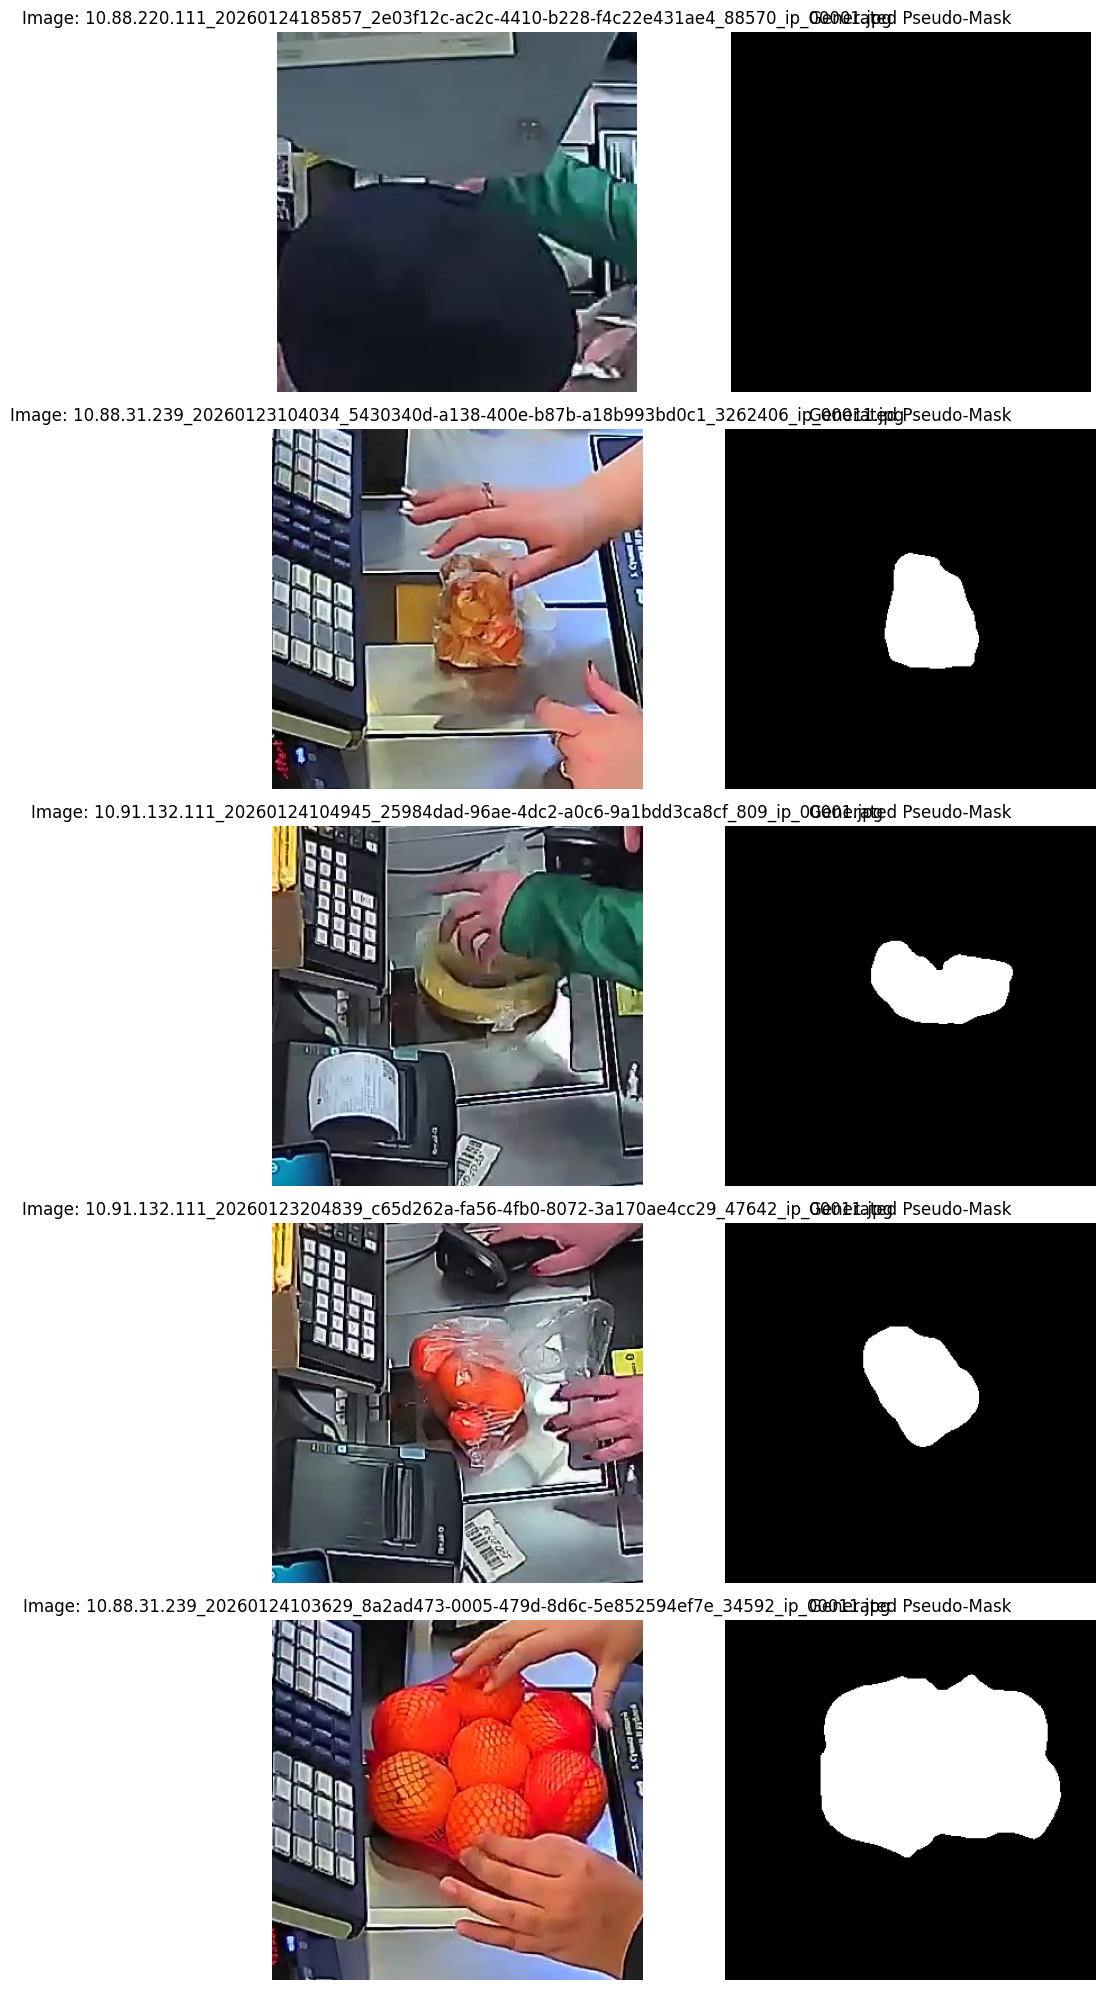

In [ ]:
import matplotlib.pyplot as plt
import random

# Select a few random samples to visualize
sample_paths = random.sample(image_paths, min(5, len(image_paths)))

fig, axes = plt.subplots(len(sample_paths), 2, figsize=(10, 4 * len(sample_paths)))
if len(sample_paths) == 1:
    axes = [axes]

for i, img_path in enumerate(sample_paths):
    # Load image
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Load corresponding generated mask
    mask_path = OUTPUT_MASKS_DIR / f"{img_path.stem}.png"
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    # Plot
    axes[i][0].imshow(img_rgb)
    axes[i][0].set_title(f"Image: {img_path.name}")
    axes[i][0].axis("off")

    axes[i][1].imshow(mask, cmap="gray")
    axes[i][1].set_title("Generated Pseudo-Mask")
    axes[i][1].axis("off")

plt.tight_layout()
plt.show()